<a href="https://colab.research.google.com/github/zaibshahzadi/ML-Internship/blob/main/Wine_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
df = pd.read_csv("WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
X = df.drop(["quality", "Id"], axis=1)   # inputs (remove Id too)
y = df["quality"]                        # output

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
preprocessor = StandardScaler()

In [5]:
dt_pipeline = Pipeline([("scaler", preprocessor),
                        ("model", DecisionTreeClassifier(random_state=42))])

knn_pipeline = Pipeline([("scaler", preprocessor),
                         ("model", KNeighborsClassifier(n_neighbors=5))])

nb_pipeline = Pipeline([("scaler", preprocessor),
                        ("model", GaussianNB())])

In [6]:
pipelines = {"Decision Tree": dt_pipeline,
             "kNN": knn_pipeline,
             "Naive Bayes": nb_pipeline}

results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name} Results:")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Decision Tree Results:
Accuracy: 0.5327510917030568
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.14      0.17      0.15         6
           5       0.63      0.58      0.61        96
           6       0.53      0.53      0.53        99
           7       0.45      0.50      0.47        26
           8       0.00      0.00      0.00         2

    accuracy                           0.53       229
   macro avg       0.29      0.30      0.29       229
weighted avg       0.55      0.53      0.54       229

Confusion Matrix:
 [[ 0  0  0  0  0  0]
 [ 0  1  2  2  1  0]
 [ 3  4 56 31  2  0]
 [ 2  2 31 52 12  0]
 [ 0  0  0 13 13  0]
 [ 0  0  0  1  1  0]]

kNN Results:
Accuracy: 0.5589519650655022
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.61      0.69      0.64        96
           6       0.54      0.56      0.55        9

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

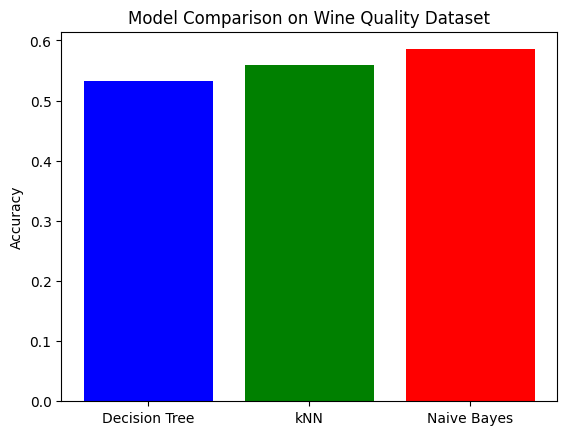

In [7]:
plt.bar(results.keys(), results.values(), color=["blue","green","red"])
plt.ylabel("Accuracy")
plt.title("Model Comparison on Wine Quality Dataset")
plt.show()

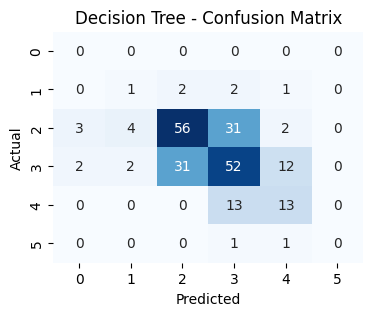

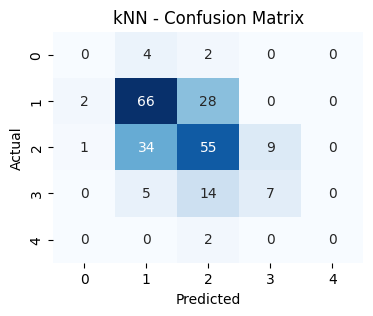

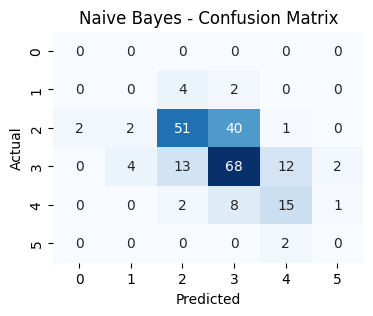

In [8]:
for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()